<a href="https://colab.research.google.com/github/ionikim/epilepsy_pediatrics_EEG/blob/main/src/01_loading/preprocessing_150326.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Following marina's file, here I preprocessed another EEG recording from the same patient during seizure onset (for file chb01_15, and seizure annotated on the chb01_15.seizure file)

In [49]:
from google.colab import files
uploaded = files.upload()

Saving chb01_15.edf to chb01_15 (3).edf
Saving chb01_15_annotation.edf.seizures to chb01_15_annotation.edf.seizures


In [50]:
# libraries for the preprocessing
!pip install mne
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [47]:
os.listdir()

['.config',
 'chb01_15 (2).edf',
 'chb01_15.edf',
 'chb01_15 (1).edf',
 'chb01_15.edf.seizures.seizures',
 'sample_data']

01. Loading Data

    01-1. Loading EEG data

Extracting EDF parameters from chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_1140/1646767560.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_15 = mne.io.read_raw_edf('chb01_15.edf', preload=True)


Number of channels: 23
Number of samples: 921600


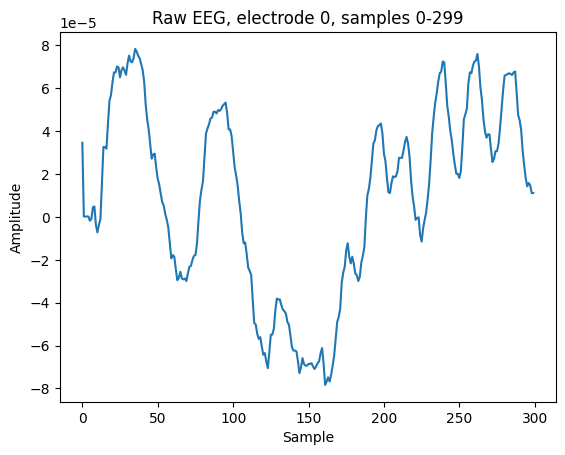

In [59]:
# Load Data

raw_15 = mne.io.read_raw_edf('chb01_15.edf', preload=True)

# raw signal array load
raw_data_15 = raw_15.get_data()

# test
print("Number of channels:", raw_data_15.shape[0])
print("Number of samples:", raw_data_15.shape[1])

plt.plot(raw_data_15[0, :300])
plt.title("Raw EEG, electrode 0, samples 0-299")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

01-2. loading seizure annotation

In [60]:
def get_seizure_period(annotation_file):

    with open(annotation_file, "rb") as f:
        byte_array = f.read()

    start = int(bin(byte_array[38])[2:] + bin(byte_array[41])[2:], 2)
    length = byte_array[49]

    return start, length

In [62]:
start, length = get_seizure_period("chb01_15.edf.seizures.seizures")

print("Seizure start:", start)
print("Seizure length:", length)
print("Seizure end:", start + length)

Seizure start: 1732
Seizure length: 40
Seizure end: 1772


02.Filtering

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_1140/637441708.py:8: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig_before = psd_before.plot(show=False)


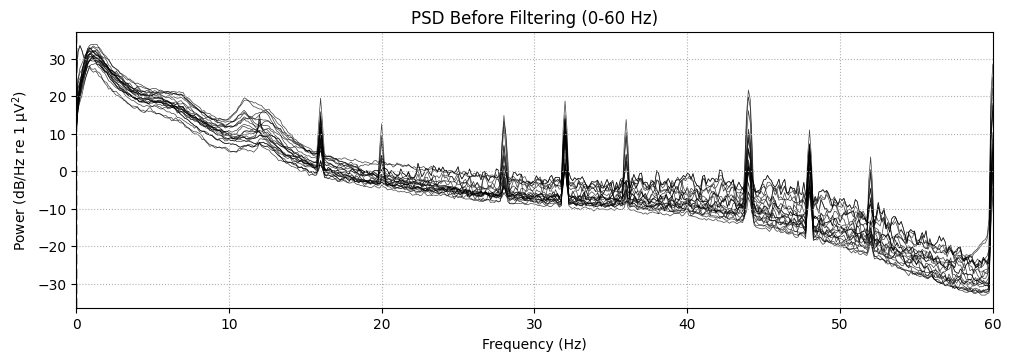

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_1140/637441708.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_after.plot(show=False)


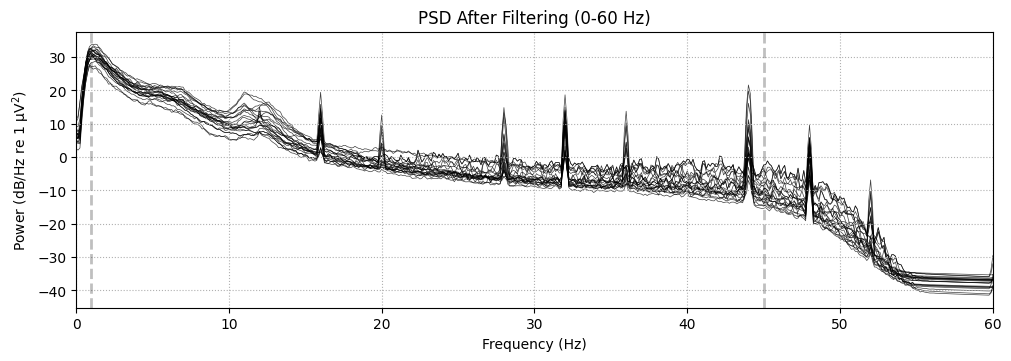

In [ ]:
# filtering

# 1. Band-pass filtering
filtered_raw_15 = raw_15.copy().filter(l_freq=1.0, h_freq=45.0)

# 2. psd(power spectral density) before filtering
psd_before = raw_15.compute_psd(fmax=60)
fig_before = psd_before.plot(show=False)
plt.title("PSD Before Filtering (0-60 Hz)")
plt.show()

#3. psd after filtering
psd_after = filtered_raw_15.compute_psd(fmax=60)
psd_after.plot(show=False)
plt.title("PSD After Filtering (0-60 Hz)")
plt.show()

03.re-referencing data

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


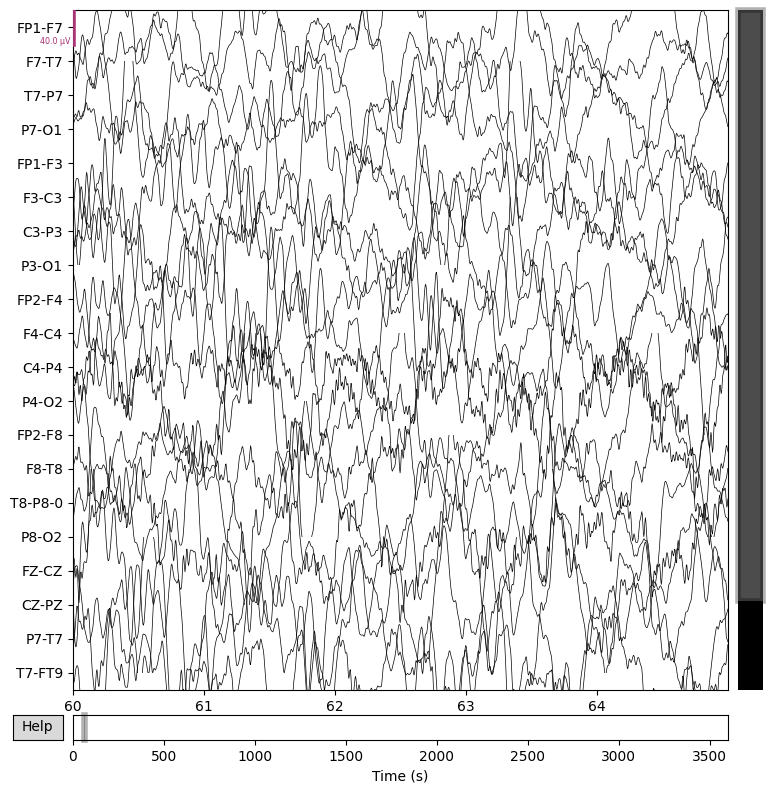

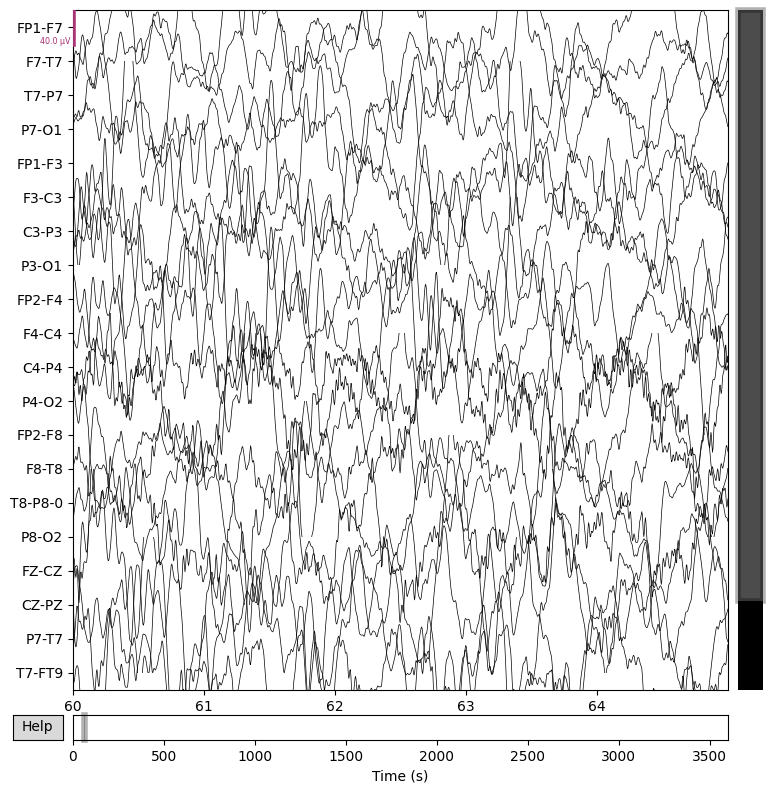

In [ ]:
# re-referencing data
processed_raw = filtered_raw_15.copy()
processed_raw.set_eeg_reference('average')

# Visualization
processed_raw.plot(start=60, duration=5)

04. creating an array

In [ ]:
# get electrode names
electrode_names = processed_raw.ch_names

# get sampling frequency
sfreq = processed_raw.info['sfreq']

# calculate time points in seconds
n_samples = len(processed_raw.times)
time_marks = np.arange(n_samples) / sfreq

# electrode data
electrode_data = processed_raw.get_data()

# create DataFrame
df = pd.DataFrame(electrode_data.T, columns=electrode_names)

# time as index
df.index = time_marks
df.index.name = 'Time (s)'

display(df.head())

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,F8-T8,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000000,-5.745093e-21,-4.640267e-20,1.458370e-20,-5.745093e-21,-1.252136e-20,-5.995520e-20,-5.745093e-21,2.135996e-20,-1.929762e-20,-3.285015e-20,...,-1.929762e-20,7.807434e-21,1.297802e-19,7.807434e-21,2.813622e-20,-2.607388e-20,4.168875e-20,-4.979081e-20,-1.590949e-20,7.807434e-21
0.003906,5.720228e-05,1.334602e-04,1.075441e-05,-1.003093e-04,7.186760e-05,7.021685e-05,3.779674e-06,-4.473565e-05,8.299869e-05,3.641751e-05,...,1.064253e-04,2.990767e-05,-4.008442e-04,2.959964e-05,-5.099120e-05,1.483973e-04,-1.473219e-04,2.278430e-04,7.342972e-05,2.990767e-05
0.007812,8.927366e-05,2.099841e-04,1.713179e-05,-1.563617e-04,1.127198e-04,1.104094e-04,5.634313e-06,-6.858901e-05,1.308262e-04,5.732456e-05,...,1.697005e-04,4.689318e-05,-6.325457e-04,4.617629e-05,-8.092584e-05,2.332274e-04,-2.322634e-04,3.580084e-04,1.182447e-04,4.689318e-05
0.011719,9.148235e-05,2.184314e-04,1.844967e-05,-1.591412e-04,1.166468e-04,1.145705e-04,5.813522e-06,-6.750578e-05,1.366297e-04,6.004226e-05,...,1.813625e-04,4.869098e-05,-6.633421e-04,4.754191e-05,-8.463958e-05,2.417087e-04,-2.417279e-04,3.707050e-04,1.282033e-04,4.869098e-05
0.015625,7.989256e-05,1.938156e-04,1.732321e-05,-1.366113e-04,1.030342e-04,1.011703e-04,5.969361e-06,-5.544932e-05,1.218964e-04,5.427590e-05,...,1.664724e-04,4.348854e-05,-5.967181e-04,4.217300e-05,-7.413504e-05,2.129213e-04,-2.134331e-04,3.259430e-04,1.188177e-04,4.348854e-05


05. segmenting into 5 second windows

    05-1. Segmentation

In [ ]:
window_size = 5  # seconds

# assign window number to each time sample
df['window'] = (df.index // window_size).astype(int)

# group data by window
df_windows = df.drop(columns='window').groupby(df['window']).agg(list)

# check result
display(df_windows.head())
print("Shape:", df_windows.shape)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,F8-T8,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1
window,,,,,,,,,,,,,,,,,,,,,
0,"[-5.745093033550908e-21, 5.7202276825605535e-0...","[-4.640267450175732e-20, 0.0001334601954958965...","[1.45836977005523e-20, 1.0754409504594879e-05,...","[-5.745093033550908e-21, -0.000100309321754205...","[-1.2521356611585311e-20, 7.186759588369827e-0...","[-5.995520165782613e-20, 7.021685151670436e-05...","[-5.745093033550908e-21, 3.7796737899425335e-0...","[2.1359961278586703e-20, -4.473564649119345e-0...","[-1.9297620189619714e-20, 8.299869376729022e-0...","[-3.2850147345688516e-20, 3.6417507994598156e-...",...,"[-1.9297620189619714e-20, 0.000106425268056532...","[7.807434122517897e-21, 2.9907673151503543e-05...","[1.2978017852713714e-19, -0.000400844237274899...","[7.807434122517897e-21, 2.9599639231125957e-05...","[2.813622485662111e-20, -5.099119918857636e-05...","[-2.6073883767654116e-20, 0.000148397256433898...","[4.1688752012689914e-20, -0.000147321898578660...","[-4.979080629077452e-20, 0.0002278429756621551...","[-1.5909488400602512e-20, 7.342972233336469e-0...","[7.807434122517897e-21, 2.9907673151503543e-05..."
1,"[-1.1545715625185255e-06, 3.562830648988419e-0...","[4.97576845296956e-05, 5.0224725372398397e-05,...","[4.334342942325463e-05, 4.147452921179149e-05,...","[-8.534569192919449e-05, -8.865946337617344e-0...","[-9.644566392588048e-05, -9.861014760010714e-0...","[7.950113328971163e-05, 7.838810218325457e-05,...","[2.1440521938700797e-05, 2.4266149764596952e-0...","[1.9395289223728117e-06, 2.312829195734388e-06...","[-0.0001261219320134953, -0.000127799834415418...","[7.549609670434234e-05, 7.419970118113957e-05,...",...,"[6.557234903072877e-05, 6.73883408173436e-05, ...","[-2.860169191421306e-05, -3.0566739518831695e-...","[-5.231948190280558e-05, -4.65967583330186e-05...","[5.4468819406051455e-05, 5.473278539276444e-05...","[7.363776233573637e-05, 7.933214531751387e-05,...","[-0.00010289856003343971, -0.00010277100147063...","[-1.7455914168275057e-05, -1.903516502878127e-...","[1.7382634962431993e-05, 7.614576916629166e-06...","[-3.4796606351546545e-05, -3.614836047030275e-...","[-2.860169191421306e-05, -3.0566739518831695e-..."
2,"[1.3513672456593916e-05, 1.0820931297801697e-0...","[-1.6810274739001806e-05, -1.1439913612990415e...","[-1.4740159525394516e-05, -1.2045785195330215e...","[7.07027318070515e-06, 6.60761176396595e-06, 7...","[-3.269426773915197e-05, -3.784204865518254e-0...","[-6.698626552577454e-05, -6.0576416121027885e-...","[1.2015560856582727e-05, 1.3981196591289831e-0...","[7.628832891359177e-05, 7.755462304373894e-05,...","[-7.981925711089314e-05, -7.543404801197944e-0...","[4.58185922249252e-06, 3.413580579573735e-06, ...",...,"[5.9772931346072376e-05, 5.908204687073152e-05...","[3.2356986366556653e-06, 3.584211915507496e-06...","[-1.0092664713319646e-05, -1.0833366346947682e...","[-2.0407679993589756e-05, -1.749142916530352e-...","[-3.0946867290958484e-06, -5.325876241736049e-...","[3.331320195872984e-05, 3.0573152460940066e-05...","[6.108416786125133e-05, 5.787008359081395e-05,...","[-4.96181090905234e-05, -5.005370240283831e-05...","[-9.225077980406987e-06, -8.789116594987532e-0...","[3.2356986366556653e-06, 3.584211915507496e-06..."
3,"[-3.4659213586294126e-05, -3.14146738778134e-0...","[1.5765785881829257e-05, 2.2475078958081414e-0...","[1.9020466722596945e-05, 2.0826643488051618e-0...","[2.8810794481697695e-05, 2.3304650147038442e-0...","[-5.1125353582481466e-05, -4.238465654631565e-...","[8.375081115440004e-05, 8.471899790712079e-05,...","[-2.516521507452048e-05, -2.3000621337306516e-...","[2.3135957092193406e-05, 1.749334485764543e-05...","[-3.778807694685391e-05, -2.6888985045532807e-...","[1.2204035115865955e-05, 8.068118989840599e-06...",...,"[-5.000773861620126e-05, -5.073238162245514e-0...","[9.612211869029372e-06, 9.399534561187266e-06,...","[4.9200947625957606e-05, 4.093912951669493e-05...","[5.6065259238

Shape: (720, 23)


05-02. Seizuer Labeling

In [64]:
# seizure information
seizure_start = 1732
seizure_end = 1772

labels = []

for window in df_windows.index:
    window_start = window * window_size
    window_end = window_start + window_size

    # check if window overlaps seizure period
    if (window_start < seizure_end) and (window_end > seizure_start):
        labels.append("ictal")
    else:
        labels.append("interictal")

# add label column
df_windows["label"] = labels

# check labels
print(df_windows["label"].value_counts())
display(df_windows.head())

label
interictal    711
ictal           9
Name: count, dtype: int64


,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,label
window,,,,,,,,,,,,,,,,,,,,,
0,"[-5.745093033550908e-21, 5.7202276825605535e-0...","[-4.640267450175732e-20, 0.0001334601954958965...","[1.45836977005523e-20, 1.0754409504594879e-05,...","[-5.745093033550908e-21, -0.000100309321754205...","[-1.2521356611585311e-20, 7.186759588369827e-0...","[-5.995520165782613e-20, 7.021685151670436e-05...","[-5.745093033550908e-21, 3.7796737899425335e-0...","[2.1359961278586703e-20, -4.473564649119345e-0...","[-1.9297620189619714e-20, 8.299869376729022e-0...","[-3.2850147345688516e-20, 3.6417507994598156e-...",...,"[7.807434122517897e-21, 2.9907673151503543e-05...","[1.2978017852713714e-19, -0.000400844237274899...","[7.807434122517897e-21, 2.9599639231125957e-05...","[2.813622485662111e-20, -5.099119918857636e-05...","[-2.6073883767654116e-20, 0.000148397256433898...","[4.1688752012689914e-20, -0.000147321898578660...","[-4.979080629077452e-20, 0.0002278429756621551...","[-1.5909488400602512e-20, 7.342972233336469e-0...","[7.807434122517897e-21, 2.9907673151503543e-05...",interictal
1,"[-1.1545715625185255e-06, 3.562830648988419e-0...","[4.97576845296956e-05, 5.0224725372398397e-05,...","[4.334342942325463e-05, 4.147452921179149e-05,...","[-8.534569192919449e-05, -8.865946337617344e-0...","[-9.644566392588048e-05, -9.861014760010714e-0...","[7.950113328971163e-05, 7.838810218325457e-05,...","[2.1440521938700797e-05, 2.4266149764596952e-0...","[1.9395289223728117e-06, 2.312829195734388e-06...","[-0.0001261219320134953, -0.000127799834415418...","[7.549609670434234e-05, 7.419970118113957e-05,...",...,"[-2.860169191421306e-05, -3.0566739518831695e-...","[-5.231948190280558e-05, -4.65967583330186e-05...","[5.4468819406051455e-05, 5.473278539276444e-05...","[7.363776233573637e-05, 7.933214531751387e-05,...","[-0.00010289856003343971, -0.00010277100147063...","[-1.7455914168275057e-05, -1.903516502878127e-...","[1.7382634962431993e-05, 7.614576916629166e-06...","[-3.4796606351546545e-05, -3.614836047030275e-...","[-2.860169191421306e-05, -3.0566739518831695e-...",interictal
2,"[1.3513672456593916e-05, 1.0820931297801697e-0...","[-1.6810274739001806e-05, -1.1439913612990415e...","[-1.4740159525394516e-05, -1.2045785195330215e...","[7.07027318070515e-06, 6.60761176396595e-06, 7...","[-3.269426773915197e-05, -3.784204865518254e-0...","[-6.698626552577454e-05, -6.0576416121027885e-...","[1.2015560856582727e-05, 1.3981196591289831e-0...","[7.628832891359177e-05, 7.755462304373894e-05,...","[-7.981925711089314e-05, -7.543404801197944e-0...","[4.58185922249252e-06, 3.413580579573735e-06, ...",...,"[3.2356986366556653e-06, 3.584211915507496e-06...","[-1.0092664713319646e-05, -1.0833366346947682e...","[-2.0407679993589756e-05, -1.749142916530352e-...","[-3.0946867290958484e-06, -5.325876241736049e-...","[3.331320195872984e-05, 3.0573152460940066e-05...","[6.108416786125133e-05, 5.787008359081395e-05,...","[-4.96181090905234e-05, -5.005370240283831e-05...","[-9.225077980406987e-06, -8.789116594987532e-0...","[3.2356986366556653e-06, 3.584211915507496e-06...",interictal
3,"[-3.4659213586294126e-05, -3.14146738778134e-0...","[1.5765785881829257e-05, 2.2475078958081414e-0...","[1.9020466722596945e-05, 2.0826643488051618e-0...","[2.8810794481697695e-05, 2.3304650147038442e-0...","[-5.1125353582481466e-05, -4.238465654631565e-...","[8.375081115440004e-05, 8.471899790712079e-05,...","[-2.516521507452048e-05, -2.3000621337306516e-...","[2.3135957092193406e-05, 1.749334485764543e-05...","[-3.778807694685391e-05, -2.6888985045532807e-...","[1.2204035115865955e-05, 8.068118989840599e-06...",...,"[9.612211869029372e-06, 9.399534561187266e-06,...","[4.9200947625957606e-05, 4.093912951669493e-05...","[5.606525923846847e-05, 5.384822388152232e-05,...","[-1.0806826445101178e-05, -9.08081651609917e-0...","[-7.045465574830344e-05, -7.155028783715146e-0...","[-2.6530900583985683e-05, -3.254

label
interictal    711
ictal           9
Name: count, dtype: int64
Index([346, 347, 348, 349, 350, 351, 352, 353, 354], dtype='int64', name='window')


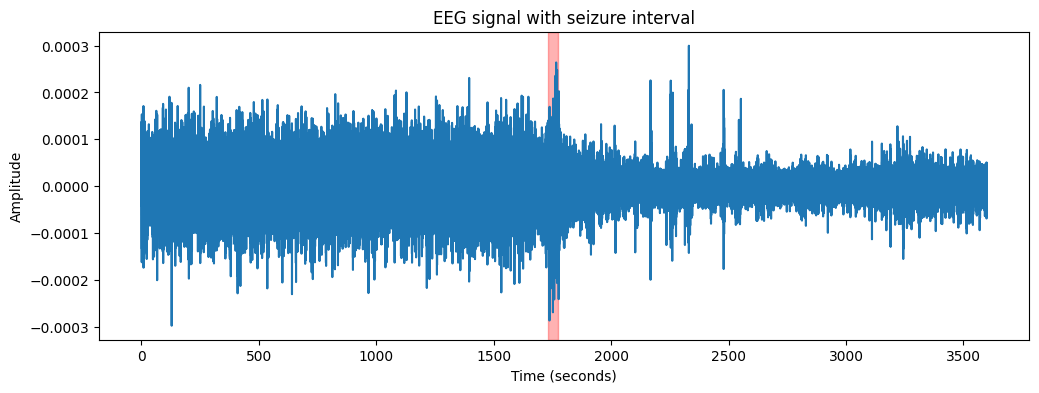

In [68]:
# check the result of labeling

print(df_windows["label"].value_counts())
print(df_windows[df_windows["label"] == "ictal"].index)

plt.figure(figsize=(12,4))

plt.plot(df.index, df["FP1-F7"])

plt.axvspan(seizure_start, seizure_end, color='red', alpha=0.3)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("EEG signal with seizure interval")

plt.show()

06. Calculating power of 5-second windows

In [69]:
signal_columns = [col for col in df_windows.columns if col != "label"]

window_power_rows = []

for window in df_windows.index:
    row = {}

    for electrode in signal_columns:
        window_values = df_windows.loc[window, electrode]
        row[electrode] = np.mean(np.array(window_values) ** 2)

    row["label"] = df_windows.loc[window, "label"]
    window_power_rows.append(row)

window_powers_df = pd.DataFrame(window_power_rows, index=df_windows.index)
window_powers_df.index.name = "window"

display(window_powers_df.head())
print(window_powers_df.shape)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,label
window,,,,,,,,,,,,,,,,,,,,,
0,3.523664e-09,2.842651e-09,1.220028e-09,3.512421e-09,4.131679e-09,2.282510e-09,7.516497e-10,5.047017e-09,3.812045e-09,2.335722e-09,...,1.643155e-09,1.613932e-08,2.171759e-09,2.870424e-09,5.716922e-09,3.567083e-09,6.820885e-09,1.794503e-09,1.643155e-09,interictal
1,2.972456e-09,1.273183e-09,2.006125e-09,1.737941e-09,4.939364e-09,2.966180e-09,8.857755e-10,2.574509e-09,2.977757e-09,3.705319e-09,...,2.259206e-09,2.140832e-09,5.606507e-09,2.908442e-09,3.518938e-09,1.631917e-09,3.494304e-09,9.171504e-10,2.259206e-09,interictal
2,3.007028e-09,6.576429e-10,1.006253e-09,1.889292e-09,4.363369e-09,1.628035e-09,1.070903e-09,4.022928e-09,4.786915e-09,2.533385e-09,...,2.382562e-09,2.487966e-09,2.413668e-09,4.597676e-09,5.537691e-09,2.038729e-09,3.592283e-09,9.933440e-10,2.382562e-09,interictal
3,1.176249e-09,8.376111e-10,1.211691e-09,1.181409e-09,2.439798e-09,1.950216e-09,1.336029e-09,2.821976e-09,3.582315e-09,2.534780e-09,...,1.260905e-09,1.175750e-09,4.263457e-09,3.191776e-09,3.976091e-09,2.164733e-09,2.934182e-09,6.731418e-10,1.260905e-09,interictal
4,2.561193e-09,1.398609e-09,1.823071e-09,2.067982e-09,5.039648e-09,2.949983e-09,1.562829e-09,5.776245e-09,5.278999e-09,4.000790e-09,...,2.186783e-09,5.846563e-09,6.164525e-09,4.859603e-09,4.610235e-09,3.148990e-09,4.724640e-09,1.421439e-09,2.186783e-09,interictal


(720, 24)


07. Check the ictal windows

In [71]:
ictal_df = window_powers_df[window_powers_df["label"] == "ictal"]
interictal_df = window_powers_df[window_powers_df["label"] == "interictal"]

print("ictal windows:", len(ictal_df))
print("interictal windows:", len(interictal_df))

display(ictal_df.head())

ictal windows: 9
interictal windows: 711


,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,label
window,,,,,,,,,,,,,,,,,,,,,
346,3.091744e-09,1.055718e-09,1.814008e-09,1.290928e-09,7.030047e-09,1.972383e-09,1.038861e-09,2.435549e-09,7.707478e-09,4.114839e-09,...,5.069831e-09,3.681779e-09,3.539891e-09,3.521859e-09,4.586117e-09,1.838398e-09,8.355828e-09,1.962243e-09,5.069831e-09,ictal
347,7.272367e-09,2.672538e-09,1.903325e-09,1.978780e-09,1.698301e-08,3.087871e-09,2.400343e-09,6.998672e-09,1.142316e-08,9.023751e-09,...,7.517698e-09,2.105635e-08,1.355946e-08,8.072382e-09,9.451771e-09,4.105742e-09,4.567375e-08,7.079904e-09,7.517698e-09,ictal
348,3.016523e-09,5.620176e-09,3.743610e-09,5.234986e-09,6.119362e-09,3.657389e-09,2.019719e-09,4.208810e-09,6.592919e-09,5.223147e-09,...,4.077845e-09,2.860275e-09,5.266111e-09,6.485455e-09,9.971929e-09,5.984219e-09,1.029787e-08,1.406467e-09,4.077845e-09,ictal
349,4.750194e-09,6.417138e-09,5.798161e-09,9.022540e-09,8.541836e-09,5.015836e-09,3.730876e-09,9.134650e-09,6.439519e-09,3.363953e-09,...,4.203379e-09,4.348498e-09,4.044200e-09,7.868949e-09,1.362033e-08,6.203107e-09,1.158158e-08,2.484038e-09,4.203379e-09,ictal
350,7.170654e-09,6.693418e-09,5.390137e-09,1.123345e-08,1.188352e-08,4.351165e-09,3.736604e-09,6.700332e-09,8.107309e-09,4.986522e-09,...,1.305764e-08,7.145969e-09,4.015574e-09,3.926242e-09,9.839826e-09,5.824493e-09,2.416369e-08,3.978209e-09,1.305764e-08,ictal


In [73]:
print(df_windows[df_windows["label"] == "ictal"].index.tolist())

[346, 347, 348, 349, 350, 351, 352, 353, 354]
